<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Observables, Measurement, and Readout

_Prepared by Claudia Zendejas-Morales_

After the feature map prepares $|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle$ and the ansatz produces
$|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle$, a QML model still needs one more ingredient:
a **readout rule** that turns the quantum state into classical information. This notebook focuses on that last stage.
We study how observables, expectation values, computational-basis probabilities, shot-based estimates, and simple
post-processing rules define the actual output seen by the rest of the learning pipeline.


## Why readout matters

The measurement stage is not an implementation detail added at the end. It is part of the model definition itself.
If the feature map and the ansatz prepare the state

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle
=
U_A(\boldsymbol{\theta})U_F(\vec{x}^{\,j})|0\rangle^{\otimes n}
$$

then the model output depends on **what** is measured and on **how** the measurement result is post-processed.
In particular, different readout choices can turn the same quantum state into a binary label, a real-valued prediction,
or a vector of measured features.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Measurement defines the usable output</b><br>
Quantum gates remain linear, but the model only becomes useful for ML after measurement turns the final quantum state
into classical information. In that sense, the readout rule is part of the model design, not only part of the implementation.
</div>


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/readout-measurement-strategies.png" alt="Measurement and readout strategies" width="700"/>
</p>

The same encoded and variationally transformed state can support several output strategies. This notebook concentrates on the three most common ones in variational QML: expectation values, probability or count based readout, and measured feature vectors followed by a simple classical rule.


## Observables and expectation values

The most common readout starts from an **<a href="https://en.wikipedia.org/wiki/Observable">observable</a>** $O$, that is, a Hermitian operator satisfying

$$
O = O^{\dagger}
$$

Given the output state $|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle$, the corresponding model output is the expectation value

$$
f_O(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | O | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$

If the observable has <a href="https://en.wikipedia.org/wiki/Spectral_theorem">spectral decomposition</a>

$$
O = \sum_m \lambda_m \Pi_m
$$

where $\lambda_m$ are eigenvalues and $\Pi_m$ are the associated projectors, then the index $m$ labels the possible measurement outcomes of that observable, or equivalently the eigenspaces on which the corresponding projectors act. So the sum runs over all outcomes encoded in the decomposition of $O$.

The outcome probabilities are then

$$
p(m \mid \vec{x}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | \Pi_m | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$

and therefore

$$
f_O(\vec{x}^{\,j}, \boldsymbol{\theta}) = \sum_m \lambda_m\,p(m \mid \vec{x}^{\,j}, \boldsymbol{\theta})
$$

In other words, an expectation value is the average measurement result one would obtain after many repetitions of the same experiment. Each possible outcome $\lambda_m$ contributes according to how likely it is, through the weight $p(m \mid \vec{x}^{\,j}, \boldsymbol{\theta})$. That is why the expression above is already a probability-weighted summary of the possible outcomes of $O$. In high-level libraries this is exactly what functions such as `qml.expval` return: the expected value of the chosen observable on the output state. For Pauli observables this is especially convenient because the output automatically stays inside a bounded interval such as $[-1,1]$.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

import pennylane as qml


The cleanest first example is to measure exact expectation values on a simulator. We prepare the same two-qubit state for many values of one angle and read it with three observables: $Z_0$, $Z_1$, and $Z_0 Z_1$.


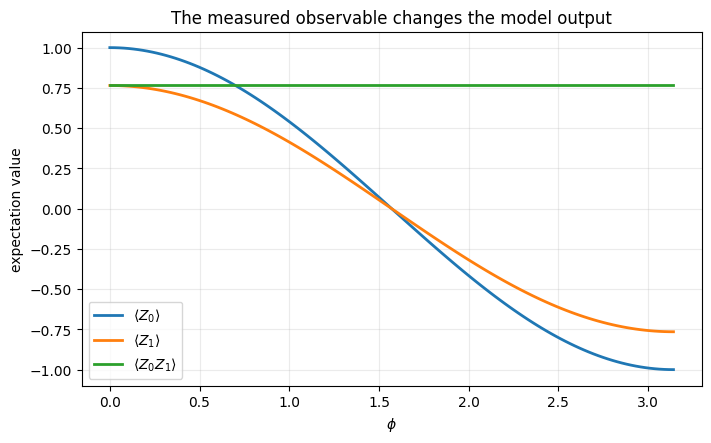

0: ──RY(0.90)─╭●─┤  <Z> ╭<Z@Z>
1: ──RY(0.70)─╰X─┤  <Z> ╰<Z@Z>

phi=0.25 -> <Z0>=0.969, <Z1>=0.741, <Z0 Z1>=0.765
phi=1.10 -> <Z0>=0.454, <Z1>=0.347, <Z0 Z1>=0.765
phi=2.30 -> <Z0>=-0.666, <Z1>=-0.510, <Z0 Z1>=0.765


In [11]:
dev_exact = qml.device("default.qubit", wires=2)

@qml.qnode(dev_exact)
def correlated_expectations(phi):
    qml.RY(phi, wires=0)
    qml.RY(0.70, wires=1)
    qml.CNOT(wires=[0, 1])
    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(0) @ qml.PauliZ(1)),
    )

phis = np.linspace(0.0, np.pi, 121)
exp_z0, exp_z1, exp_zz = [], [], []

for phi in phis:
    z0, z1, zz = correlated_expectations(phi)
    exp_z0.append(z0)
    exp_z1.append(z1)
    exp_zz.append(zz)

plt.figure(figsize=(8, 4.6))
plt.plot(phis, exp_z0, label=r"$\langle Z_0 \rangle$", linewidth=2)
plt.plot(phis, exp_z1, label=r"$\langle Z_1 \rangle$", linewidth=2)
plt.plot(phis, exp_zz, label=r"$\langle Z_0 Z_1 \rangle$", linewidth=2)
plt.xlabel(r"$\phi$")
plt.ylabel("expectation value")
plt.title("The measured observable changes the model output")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(qml.draw(correlated_expectations)(0.90))
print()
for phi in [0.25, 1.10, 2.30]:
    z0, z1, zz = correlated_expectations(phi)
    print(f"phi={phi:.2f} -> <Z0>={z0:.3f}, <Z1>={z1:.3f}, <Z0 Z1>={zz:.3f}")


Even though the prepared quantum state comes from a single circuit family, the three measured curves are different. This is the key readout lesson: **the observable is part of the model definition**. A one-qubit observable such as $Z_0$ only probes one marginal aspect of the state, while a two-qubit observable such as $Z_0 Z_1$ probes a joint property.

In this specific example, the behavior of the curves can be explained analytically. The first qubit is rotated by the variable angle $\phi$, while the second qubit is always rotated by the fixed angle $0.70$. For this circuit one obtains

$$
\langle Z_0 \rangle = \cos(\phi),
\qquad
\langle Z_1 \rangle = \cos(0.70)\cos(\phi),
\qquad
\langle Z_0 Z_1 \rangle = \cos(0.70)
$$

This explains the plot directly. The curve for $\langle Z_0 \rangle$ goes from $1$ to $-1$ because it depends only on the variable rotation of qubit $0$. The curve for $\langle Z_1 \rangle$ follows the same cosine shape, but its amplitude is smaller because it is multiplied by the constant factor $\cos(0.70) \approx 0.76$, so it ranges only from about $0.76$ to $-0.76$. By contrast, $\langle Z_0 Z_1 \rangle$ stays constant because, in this circuit, that correlator is determined only by the fixed rotation applied to qubit $1$.

The reason is that the CNOT changes how the observable should be interpreted. For a CNOT with control qubit $0$ and target qubit $1$, the conjugation rule gives

$$
\mathrm{CNOT}^{\dagger}(Z_0 Z_1)\,\mathrm{CNOT} = Z_1
$$

So measuring $Z_0 Z_1$ after the CNOT is equivalent to measuring only $Z_1$ before the CNOT. Since the state before the CNOT is just $R_y(\phi)|0\rangle \otimes R_y(0.70)|0\rangle$, the quantity $\langle Z_0 Z_1 \rangle$ depends only on the fixed rotation of qubit $1$, and that is why it stays equal to $\cos(0.70)$ instead of varying with $\phi$.

So the plot is already showing three different ways of compressing the same quantum state family into classical information: one readout tracks the control qubit, one tracks a rescaled marginal on the target qubit, and one tracks a fixed two-qubit correlation set by the second rotation angle.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why observables matter</b><br>
An observable is the mathematical object that tells us <b>what physical quantity we are asking the circuit to return</b> when the readout is defined through expectation values or through measured observable vectors. Probability and count based readouts can also be used directly, without first choosing a single observable in that form. This is why observables matter so much in variational QML: whenever the readout is expectation-based, changing the observable changes which aspect of the quantum state is turned into classical information, even if the feature map and ansatz stay exactly the same.
</div>


### Task 1 (coding): Reproduce and extend the exact observable readout in Qiskit

Build the same two-qubit circuit in Qiskit and evaluate the exact expectation values of

- $Z_0$
- $Z_1$
- $Z_0 Z_1$
- $X_0 X_1$

over a grid of values `phis = np.linspace(0.0, np.pi, 121)`.

Then:

- plot the four curves on the same figure;
- identify one interval of $\phi$ where $\langle X_0 X_1 \rangle$ behaves noticeably differently from $\langle Z_0 Z_1 \rangle$;
- explain in a few sentences what this tells you about the choice of observable.

In Qiskit, this task is a good place to practice exact expectation values with
<a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.Statevector"><code>Statevector</code></a>
and
<a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.SparsePauliOp"><code>SparsePauliOp</code></a>.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="04-observables-measurement-and-readout-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [12]:
# Task 1 starter
phis = np.linspace(0.0, np.pi, 121)

# In Qiskit Pauli strings, "IZ" means Z on qubit 0 and I on qubit 1,
# while "ZI" means I on qubit 0 and Z on qubit 1

def qiskit_correlated_circuit(phi):
    # TODO: build the same two-qubit circuit used in the PennyLane example
    pass

def observable_curves_qiskit(phis):
    # TODO: compute the four expectation-value curves with Statevector and SparsePauliOp
    pass

# TODO:
# 1. build the curves for <Z0>, <Z1>, <Z0 Z1>, and <X0 X1>
# 2. plot them on the same axes
# 3. identify one interval where <X0 X1> differs noticeably from <Z0 Z1>
# 4. explain what that says about the role of the observable


## Probabilities, counts, and shot-based estimates

Sometimes we do not want a direct expectation value of a chosen observable. Instead, we want computational-basis probabilities or the corresponding shot counts. Let $\mathbf{b} = (b_1, \dots, b_n) \in \{0,1\}^n$ denote an $n$-bit outcome string, and let $|\mathbf{b}\rangle$ denote the corresponding computational-basis state. The coefficient $c_{\mathbf{b}}$ is the complex amplitude associated with that basis state in the output superposition. If

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle = \sum_{\mathbf{b} \in \{0,1\}^n} c_{\mathbf{b}}\,|\mathbf{b}\rangle
$$

then the probability of observing bitstring $\mathbf{b}$ in the computational basis is

$$
p_{\mathbf{b}}(\vec{x}^{\,j}, \boldsymbol{\theta}) = |c_{\mathbf{b}}|^2 = |\langle \mathbf{b} | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle|^2
$$

On a real device we estimate this probability from repeated shots:

$$
\hat p_{\mathbf{b}} = \frac{N_{\mathbf{b}}}{N_{\mathrm{shots}}}
$$

where $N_{\mathbf{b}}$ is the number of times bitstring $\mathbf{b}$ appears in $N_{\mathrm{shots}}$ repetitions. For a single-qubit $Z$ measurement this gives

$$
\widehat{\langle Z \rangle} = \hat p_0 - \hat p_1 = \frac{N_0 - N_1}{N_{\mathrm{shots}}}
$$

More generally, if the measurement outcomes are $m_1, \dots, m_{N_{\mathrm{shots}}}$, the sample mean

$$
\hat \mu = \frac{1}{N_{\mathrm{shots}}} \sum_{t=1}^{N_{\mathrm{shots}}} m_t
$$

is a shot-based estimator of the exact expectation value.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Shot noise is structural, not accidental</b><br>
On a simulator we can often compute exact probabilities or exact expectation values. On hardware, however, the output of the circuit is fundamentally estimated from repeated samples. Increasing the shot budget reduces estimator variance, but it also increases runtime and experimental cost.
</div>


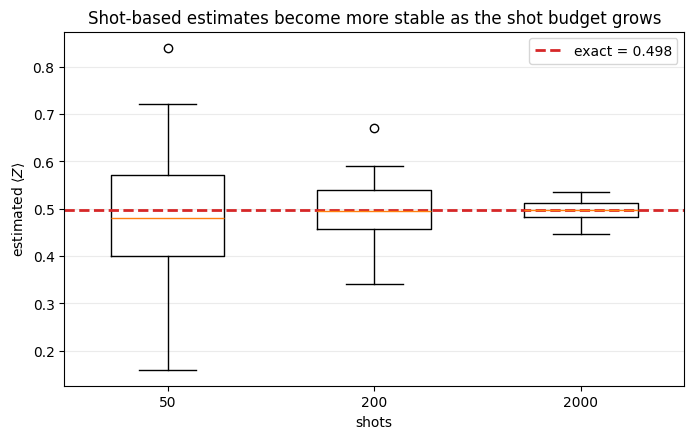

shots=  50 -> mean=0.4860, std=0.1276
shots= 200 -> mean=0.4959, std=0.0618
shots=2000 -> mean=0.4959, std=0.0195


In [13]:
def qiskit_bitstring_counts(phi, shots, seed):
    qc = QuantumCircuit(1)
    qc.ry(phi, 0)
    sv = Statevector.from_instruction(qc)
    sv.seed(seed)
    return sv.sample_counts(shots=shots)

def estimate_z_from_bitstring_counts(counts, shots):
    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)
    return (n0 - n1) / shots

phi_fixed = 1.05
shots_list = [50, 200, 2000]
repeats = 80

qc_exact = QuantumCircuit(1)
qc_exact.ry(phi_fixed, 0)
exact_probs = Statevector.from_instruction(qc_exact).probabilities()
exact_z = exact_probs[0] - exact_probs[1]

estimates = {}
for shots in shots_list:
    trial_values = []
    for seed in range(repeats):
        counts = qiskit_bitstring_counts(phi_fixed, shots=shots, seed=seed)
        trial_values.append(estimate_z_from_bitstring_counts(counts, shots))
    estimates[shots] = np.array(trial_values)

plt.figure(figsize=(8, 4.6))
data = [estimates[shots] for shots in shots_list]
plt.boxplot(data, tick_labels=[str(shots) for shots in shots_list], widths=0.55)
plt.axhline(exact_z, color="#d62728", linestyle="--", linewidth=2, label=f"exact = {exact_z:.3f}")
plt.xlabel("shots")
plt.ylabel(r"estimated $\langle Z \rangle$")
plt.title("Shot-based estimates become more stable as the shot budget grows")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.show()

for shots in shots_list:
    values = estimates[shots]
    print(f"shots={shots:4d} -> mean={values.mean():.4f}, std={values.std(ddof=1):.4f}")


The exact expectation value is the same in all cases, but the empirical spread of the estimator shrinks as the shot budget grows. This is why one cannot talk about readout quality without also talking about shot cost. A readout rule that looks simple algebraically may still be expensive if it requires many repeated circuit evaluations.


### Task 2 (coding): Reproduce the shot-noise experiment in PennyLane

Repeat the same experiment in PennyLane for the one-qubit state $R_y(\phi)|0\rangle$ with `phi = 1.05`.
Use the shot budgets

- `50`
- `200`
- `2000`

and estimate $\langle Z \rangle$ many times from sampled outcomes. Your work should include:

- an exact reference value obtained from `qml.expval`;
- repeated shot-based estimates obtained from `qml.sample`;
- the empirical mean and empirical standard deviation for each shot budget;
- one figure that makes the reduction in sampling spread visually clear.

Official references that may help:

- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.expval.html"><code>qml.expval</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.sample.html"><code>qml.sample</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.PauliZ.html"><code>qml.PauliZ</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.set_shots.html"><code>qml.set_shots</code></a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="04-observables-measurement-and-readout-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [14]:
# Task 2 starter
phi = 1.05
shots_list = [50, 200, 2000]
repeats = 80

def exact_z_pennylane(phi):
    # TODO: return the exact expectation value of Z with qml.expval
    pass

def sampled_z_estimates_pennylane(phi, shots, repeats=80, base_seed=0):
    # TODO: return many shot-based estimates of <Z> using qml.sample and qml.set_shots
    pass

# TODO:
# 1. compute the exact value once
# 2. generate repeated estimates for each shot budget
# 3. report empirical mean and empirical standard deviation
# 4. make one plot that shows how the estimator spread changes with shots


## Binary classification readout strategies

A variational circuit often ends in a binary decision rule, but several different readout rules can be used even for the same state.

A single-observable sign rule may map

$$
\hat y_{\mathrm{sign}}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\operatorname{sign}\left(\langle Z_0 \rangle\right) \in \{-1,+1\}
$$

A threshold rule may instead use a marginal probability such as $p_1^{(0)} = \Pr(b_0 = 1)$ and define

$$
\hat y_{\tau}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\mathbf{1}\left[p_1^{(0)} \ge \tau\right]
$$

A parity rule uses the parity of the measured bitstring. For an $m$-qubit measured register,

$$
\pi(\mathbf{b}) = (-1)^{\sum_{q=1}^{m} b_q}
$$

and the corresponding expectation is

$$
\langle Z^{\otimes m} \rangle
=
\sum_{\mathbf{b} \in \{0,1\}^m} \pi(\mathbf{b})\,p_{\mathbf{b}}
$$


Here $\operatorname{sign}(u)$ returns $+1$ if $u \ge 0$ and $-1$ if $u < 0$. The symbol $\mathbf{1}[\cdot]$ denotes the indicator function, which returns $1$ when the condition inside the brackets is true and $0$ otherwise. The symbol $\pi(\mathbf{b})$ is the parity function of the measured bitstring $\mathbf{b}$, so it returns $+1$ for even <a href="https://en.wikipedia.org/wiki/Hamming_weight">Hamming weight</a> and $-1$ for odd Hamming weight.

These rules are related, but they are not interchangeable. Thresholding one qubit and taking the parity of several qubits generally produce different classifiers because they compress different information from the same state.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>The observable and the label map are different choices</b><br>
Measuring an observable produces a numerical quantity. Turning that quantity into a class label is a second design choice. For example, one may threshold a probability, threshold an expectation value, or use parity on a measured bitstring. Those are different classical readout maps placed on top of the quantum circuit.
</div>


phi      <Z0>     p(b0=1)     full parity   sign(<Z0>)  threshold(p(b0=1)>=0.5)
0.20    0.980      0.010         0.445          +1               0
0.85    0.660      0.170         0.684          +1               0
1.50    0.071      0.465         0.865          +1               0
2.35   -0.703      0.851         0.990          -1               1


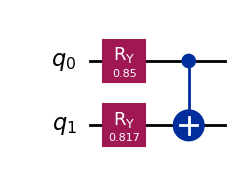

In [15]:
def binary_readout_circuit(phi):
    qc = QuantumCircuit(2)
    qc.ry(phi, 0)
    qc.ry(1.20 - 0.45 * phi, 1)
    qc.cx(0, 1)
    return qc

def full_parity_from_probs_dict(probs_dict):
    parity = 0.0
    for b_string, prob in probs_dict.items():
        parity += ((-1) ** b_string.count("1")) * prob
    return parity

sample_phis = [0.20, 0.85, 1.50, 2.35]

print("phi      <Z0>     p(b0=1)     full parity   sign(<Z0>)  threshold(p(b0=1)>=0.5)")
for phi in sample_phis:
    qc = binary_readout_circuit(phi)
    sv = Statevector.from_instruction(qc)
    marginal_b0 = sv.probabilities([0])
    p_b0_eq_1 = marginal_b0[1]
    exp_z0 = marginal_b0[0] - marginal_b0[1]
    parity = full_parity_from_probs_dict(sv.probabilities_dict())
    sign_label = +1 if exp_z0 >= 0 else -1
    threshold_label = 1 if p_b0_eq_1 >= 0.5 else 0
    print(f"{phi:3.2f}   {exp_z0:6.3f}    {p_b0_eq_1:7.3f}       {parity:7.3f}          {sign_label:+d}               {threshold_label}")

display(binary_readout_circuit(sample_phis[1]).draw("mpl"))


The same state can therefore support several binary outputs. The sign rule uses one expectation value and produces labels in $\{-1,+1\}$. The threshold rule uses one marginal probability and produces labels in $\{0,1\}$. The parity rule summarizes the whole measured register and is sensitive to joint bitstring structure rather than only to one marginal qubit.


### Task 3 (coding): Compare parity readouts on different measured subsets in PennyLane

Use the same idea as the example above, but now work with a **three-qubit** circuit in PennyLane and compare two parity rules:

- the parity of the full three-qubit register;
- the parity of only the first two measured qubits.

Use the circuit skeleton

```python
qml.RY(phi, wires=0)
qml.RY(0.85, wires=1)
qml.RY(1.10 - 0.30 * phi, wires=2)
qml.CNOT(wires=[0, 1])
qml.CNOT(wires=[1, 2])
```

on the values `phis = [0.20, 0.90, 1.60, 2.30]`.

For each value of `phi`:

- compute the exact computational-basis probabilities with `qml.probs`;
- compute the full-register parity expectation;
- compute the two-qubit parity expectation for qubits `0` and `1` only;
- state which `phi` values are affected most by the third qubit.

Your conclusion should explain why these two parity rules are not equivalent, even though they come from the same quantum state.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="04-observables-measurement-and-readout-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


In [16]:
# Task 3 starter
phis = [0.20, 0.90, 1.60, 2.30]

def three_qubit_probs(phi):
    # TODO: return the exact computational-basis probabilities with a PennyLane QNode
    pass

def probs_array_to_dict(probs):
    # TODO: map the probabilities array to bitstrings such as "000", "001", ...
    pass

def parity_from_probabilities_dict(probs_dict):
    # TODO: compute full-register parity from a probabilities dictionary
    pass

def parity_on_subset_from_probabilities_dict(probs_dict, subset):
    # TODO: compute parity only on the selected qubit subset
    pass

# TODO:
# 1. evaluate the exact probabilities for each phi with PennyLane
# 2. compare full parity with parity on qubits [0, 1]
# 3. identify the values of phi most affected by the third qubit
# 4. explain why the two parity rules are not equivalent


## Multi-observable and multi-basis readout

A richer readout does not need to collapse everything into a single scalar immediately. One may instead measure a vector of observables,

$$
\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\bigl(\langle O_1 \rangle, \langle O_2 \rangle, \dots, \langle O_R \rangle\bigr)
$$

and only afterwards apply a classical rule such as a linear map

$$
\hat y(\vec{x}^{\,j}, \boldsymbol{\theta})
=
b + \sum_{r=1}^{R} w_r\,m_r(\vec{x}^{\,j}, \boldsymbol{\theta})
=
b + \mathbf{w}^{\top}\mathbf{m}(\vec{x}^{\,j}, \boldsymbol{\theta})
$$

This is often called a **simple linear readout**. It is especially useful when one wants several measured features from the same circuit family before making a final prediction.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Commuting and non-commuting observables</b><br>
If the chosen observables <a href="https://en.wikipedia.org/wiki/Commuting_square">commute</a>, they can often be estimated from the same measurement setting. If they do not commute, then separate basis settings or separate circuit evaluations are required. In a simulator this can be easy to hide behind a high-level API, but in hardware-aware practice it matters for shot cost and execution time.
</div>


In [17]:
dev_readout = qml.device("default.qubit", wires=2)

@qml.qnode(dev_readout)
def z_basis_head(sample):
    qml.AngleEmbedding(sample, wires=[0, 1], rotation="Y")
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(1))

@qml.qnode(dev_readout)
def x_basis_head(sample):
    qml.AngleEmbedding(sample, wires=[0, 1], rotation="Y")
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliX(0))

def measured_feature_vector(sample):
    z0, z1 = z_basis_head(sample)
    x0 = x_basis_head(sample)
    return np.array([z0, z1, x0], dtype=float)

def linear_readout(sample, weights, bias):
    features = measured_feature_vector(sample)
    return features, bias + np.dot(weights, features)

weights = np.array([0.90, -0.55, 0.40])
bias = -0.10
samples_for_readout = [
    np.array([0.20, 0.40]),
    np.array([0.90, 0.60]),
    np.array([1.40, 0.25]),
]

print(qml.draw(z_basis_head)(samples_for_readout[0]))
print()
print(qml.draw(x_basis_head)(samples_for_readout[0]))
print()

for sample in samples_for_readout:
    features, y_hat = linear_readout(sample, weights, bias)
    print(f"sample={sample} -> measured features={np.round(features, 3)}, linear readout={y_hat:.3f}")


0: ─╭AngleEmbedding(M0)─╭●─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰X─┤  <Z>

M0 = 
[0.2 0.4]

0: ─╭AngleEmbedding(M0)─╭●─┤  <X>
1: ─╰AngleEmbedding(M0)─╰X─┤     

M0 = 
[0.2 0.4]

sample=[0.2 0.4] -> measured features=[0.98  0.903 0.077], linear readout=0.317
sample=[0.9 0.6] -> measured features=[0.622 0.513 0.442], linear readout=0.354
sample=[1.4  0.25] -> measured features=[0.17  0.165 0.244], linear readout=0.060


Here the measured vector combines two $Z$-basis expectations with one $X$-basis expectation. The linear readout is classical, but it acts on quantum-measured features. This already looks like a small hybrid head. The next notebook will assemble that idea into a full variational model with a reusable forward pass.

The printed numbers already show why this can be useful. For the first sample, both $\langle Z_0 \rangle$ and $\langle Z_1 \rangle$ are close to $1$ (`[0.98  0.903 0.077]`), which means the state still has strong weight near the computational-basis ground state. As the input angles grow, those two $Z$-basis expectations decrease, but $\langle X_0 \rangle$ does not simply mirror them: it captures a different aspect of the state, related to coherence in the $X$ basis. This is why the measured feature vectors are not redundant. The final linear score is then not just “one measurement result,” but a weighted combination of several quantum-measured features, and two samples can end with similar scalar outputs even when the composition of their measured vectors is different.

### Task 4 (coding): Compare a smaller and a richer linear readout head in Qiskit

Using Qiskit and the same circuit skeleton as in the example above, compare two readout heads on the sample set

```python
samples_task = [
    np.array([0.15, 0.35]),
    np.array([0.65, 0.55]),
    np.array([1.05, 0.80]),
    np.array([1.40, 0.20]),
]
```

Define:

- a **small** head with measured vector $(\langle Z_0 \rangle, \langle Z_1 \rangle)$;
- a **richer** head with measured vector $(\langle Z_0 \rangle, \langle Z_1 \rangle, \langle X_0 \rangle)$.

Choose one weight vector and one bias for each head, evaluate both heads on all samples, and then answer:

- Does the extra $X$-basis component change the ordering or the sign of the outputs for any samples?
- What extra measurement cost would this richer head imply outside a simulator?

Official references that may help:

- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.Statevector"><code>Statevector</code></a>
- <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.0/qiskit.quantum_info.SparsePauliOp"><code>SparsePauliOp</code></a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 4 solution:</b> <a href="04-observables-measurement-and-readout-solutions.ipynb#task4-solution">Click here for Task 4 solution</a>
</div>


In [18]:
# Task 4 starter
samples_task = [
    np.array([0.15, 0.35]),
    np.array([0.65, 0.55]),
    np.array([1.05, 0.80]),
    np.array([1.40, 0.20]),
]

def qiskit_readout_circuit(sample):
    # TODO: build the same circuit skeleton used in the example above
    pass

def z_features(sample):
    # TODO: return (<Z0>, <Z1>) using Statevector and SparsePauliOp
    pass

def x_feature(sample):
    # TODO: return <X0> for the same circuit skeleton
    pass

def linear_head(sample, weights, bias, use_x_term=False):
    # TODO: build the measured feature vector and evaluate the linear readout
    pass

# TODO:
# 1. choose weights and a bias for the small head and for the richer head
# 2. evaluate both heads on every sample
# 3. compare ordering and sign changes between the two heads
# 4. explain the extra measurement cost implied by the X-basis term


## Closing remarks

Readout is where the quantum state becomes a usable ML signal. A variational circuit can be read through exact expectation values, sampled probabilities, bitstring rules such as parity, or a vector of measured observables followed by classical post-processing. Those are not minor implementation details: they define what the model output actually is.

The next notebook brings the pieces together and shows how to assemble a reusable variational QML forward pass from a feature map, an ansatz, and a readout rule.
